c:\Users\alexg\miniconda3\envs\tf-gpu\lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


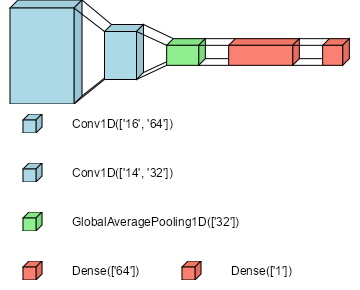

In [ ]:
from PIL import ImageFont
import visualkeras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, Dense, Input
from tensorflow.keras import layers

model = Sequential([
    Input(shape=(18, 1)),
    Conv1D(64, 3),
    Conv1D(32, 3),
    GlobalAveragePooling1D(),
    Dense(64),
    Dense(1)
])

# Optional: load a custom font (use a TTF path available on your system)
try:
    font = ImageFont.truetype("arial.ttf", 12)
except:
    font = None  # fallback if font not found

# Color mapping by layer type
color_map = {
    layers.Conv1D: {"fill": "lightblue"},
    layers.GlobalAveragePooling1D: {"fill": "lightgreen"},
    layers.Dense: {"fill": "salmon"},
    layers.InputLayer: {"fill": "lightgray"}
}

# Create the diagram
visualkeras.layered_view(
    model,
    legend=True,
    spacing=30,
    scale_xy=1.5,
    scale_z=1.0,
    color_map=color_map,
    draw_volume=True,
    font=font,
    show_dimension=True,
    to_file='./imgs/models/cnn.png'
)


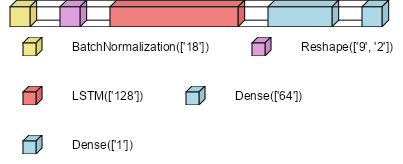

In [18]:
from tensorflow.keras.layers import BatchNormalization, Reshape, LSTM


color_map.update({
    BatchNormalization: {"fill": "khaki"},
    Reshape: {"fill": "plum"},
    LSTM: {"fill": "lightcoral"},
    layers.Dense: {"fill": "lightblue"},
})

model = Sequential([
    BatchNormalization(input_shape=(18,)),
    Reshape((9, 2)),  # reshape to sequence
    LSTM(128, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1)
])

visualkeras.layered_view(
    model,
    legend=True,
    spacing=30,
    scale_xy=1.5,
    scale_z=1.0,
    color_map=color_map,
    draw_volume=True,
    font=font,
    show_dimension=True,
    to_file='./imgs/models/lstm.png'
)

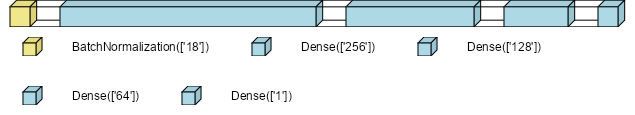

In [20]:
model = Sequential([
    BatchNormalization(input_shape=(18,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

visualkeras.layered_view(
    model,
    legend=True,
    spacing=30,
    scale_xy=1.5,
    scale_z=1.0,
    color_map=color_map,
    draw_volume=True,
    font=font,
    show_dimension=True,
    to_file='./imgs/models/neural_network.png'
)

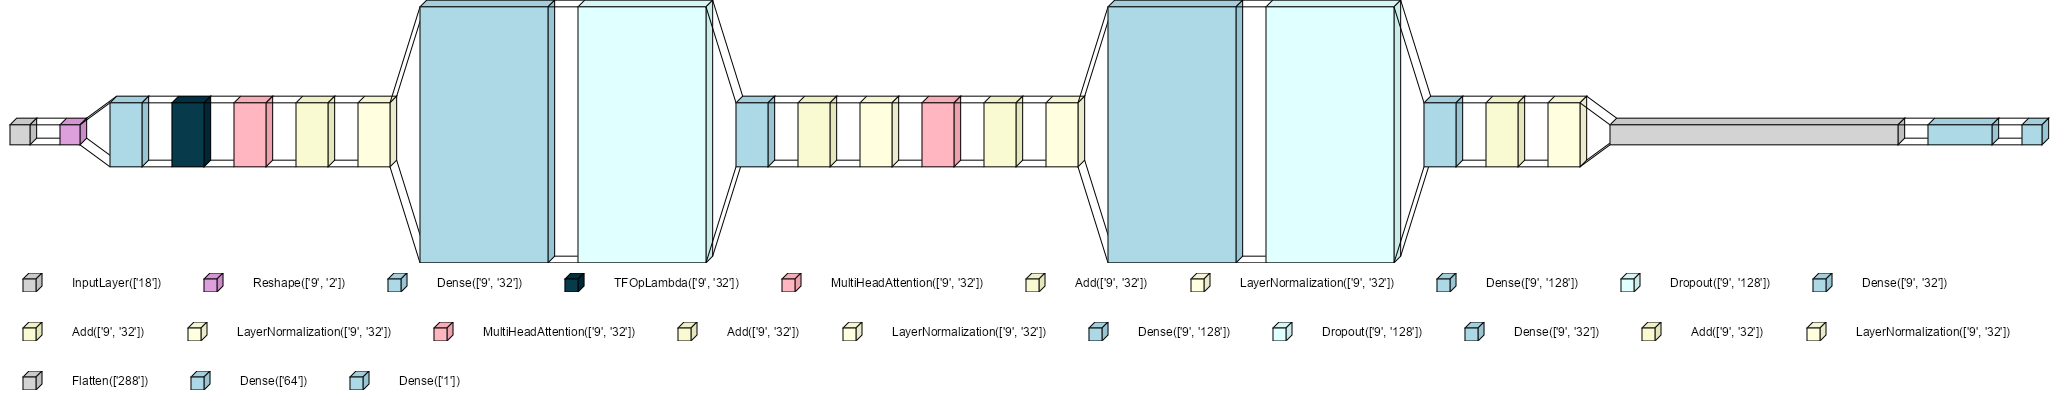

In [25]:
from keras.models import Sequential, Model
from keras.layers import Dense, BatchNormalization, Activation, Input, LayerNormalization, MultiHeadAttention, Dropout, Flatten, Reshape, Add
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.losses import Huber
from datetime import datetime
import tensorflow as tf
import numpy as np
from keras.layers import LayerNormalization, MultiHeadAttention, Dropout, Flatten
import visualkeras

def get_positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates

    pos_encoding = np.zeros_like(angle_rads)
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

# Model parameters
seq_len = 9
d_model = 32
num_heads = 2

inputs = Input(shape=(18,))
x = Reshape((9, 2))(inputs)
x = Dense(d_model, kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_len, d_model)
x += pos_encoding

# First Transformer block
attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=0.1)(x, x)
x = Add()([x, attn_output])
x = LayerNormalization(epsilon=1e-6)(x)

ffn = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-6))(x)
ffn = Dropout(0.1)(ffn)
ffn = Dense(d_model, kernel_regularizer=tf.keras.regularizers.l2(1e-6))(ffn)
x = Add()([x, ffn])
x = LayerNormalization(epsilon=1e-6)(x)

# Second Transformer block (additional)
attn_output2 = MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=0.1)(x, x)
x = Add()([x, attn_output2])
x = LayerNormalization(epsilon=1e-6)(x)

ffn2 = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-6))(x)
ffn2 = Dropout(0.1)(ffn2)
ffn2 = Dense(d_model, kernel_regularizer=tf.keras.regularizers.l2(1e-6))(ffn2)
x = Add()([x, ffn2])
x = LayerNormalization(epsilon=1e-6)(x)

# Output head
x = Flatten()(x)
x = Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-6))(x)
outputs = Dense(1)(x)

model = Model(inputs=inputs, outputs=outputs)

color_map.update({
    LayerNormalization: {"fill": "lightyellow"},
    MultiHeadAttention: {"fill": "lightpink"},
    Dropout: {"fill": "lightcyan"},
    Flatten: {"fill": "lightgray"},
    Reshape: {"fill": "plum"},
    Dense: {"fill": "lightblue"},
    Add: {"fill": "lightgoldenrodyellow"},
})

visualkeras.layered_view(
    model,
    legend=True,
    spacing=30,
    scale_xy=2,
    scale_z=1.0,
    color_map=color_map,
    draw_volume=True,
    font=font,
    show_dimension=True,
    to_file='./imgs/models/transformerpe.png'
)

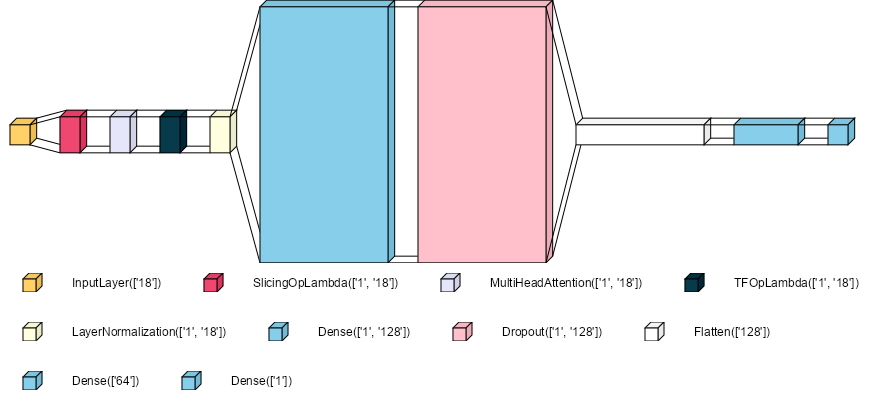

In [28]:
# Create a fresh color map without repeating imports or definitions
color_map = {
    Dense: {"fill": "skyblue"},
    BatchNormalization: {"fill": "khaki"},
    LayerNormalization: {"fill": "lightyellow"},
    MultiHeadAttention: {"fill": "lavender"},
    Dropout: {"fill": "pink"},
    Flatten: {"fill": "white"}
}

# Define a new input shape (assuming X_train is available)
input_shape = (18,)
inputs = Input(shape=input_shape)

# Add a sequence dimension for the transformer
x = inputs[:, None, :]

# Simple transformer block
attn_output = MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
x = LayerNormalization(epsilon=1e-6)(attn_output + x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.1)(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1)(x)

model = Model(inputs=inputs, outputs=outputs)

visualkeras.layered_view(
    model,
    legend=True,
    spacing=30,
    scale_xy=2,
    scale_z=1.0,
    color_map=color_map,
    draw_volume=True,
    font=font,
    show_dimension=True,
    to_file='./imgs/models/transformer.png'
)